### Establecer semilla


In [1]:
import torch
import random
import numpy as np
import os

SEED = 112

def set_seed(seed=17):
    # 1. Fija la semilla para el módulo random base de Python
    random.seed(seed)
    
    # 2. Fija la semilla en las variables de entorno
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # 3. Fija la semilla para NumPy
    np.random.seed(seed)
    
    # 4. Fija la semilla para PyTorch (CPU)
    torch.manual_seed(seed)
    
    # 5. Fija la semilla para PyTorch (GPU / CUDA)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    
    # 6. Fuerza a CuDNN a usar algoritmos deterministas (solo si se usa GPU)
    # Se prioriza la reproducibilidad determinista durante la fase experimental mediante la restricción de heurísticas de cuDNN,
    # asumiendo una ligera penalización en el rendimiento computacional a favor del rigor evaluativo.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

### Carga de archivos .parquet y análisis de distribución de servicios


Se han encontrado 7 archivos Parquet.
¡Hecho! Dataset total con 1,916,757 registros cargados.

--- CLASES DETECTADAS (8) ---
Clase 0: Benigno -> 958,109 registros
Clase 1: Credential Access -> 871,188 registros
Clase 2: Defense Evasion -> 6,048 registros
Clase 3: Exfiltration -> 559 registros
Clase 4: Initial Access -> 10,662 registros
Clase 5: Persistence -> 6,048 registros
Clase 6: Privilege Escalation -> 6,048 registros
Clase 7: Reconnaissance -> 58,095 registros

--- DISTRIBUCIÓN GLOBAL ---
             Cantidad  Porcentaje (%)
service                              
dns            879490           45.88
ssl            860606           44.90
desconocido    154477            8.06
http             9847            0.51
ntp              6628            0.35


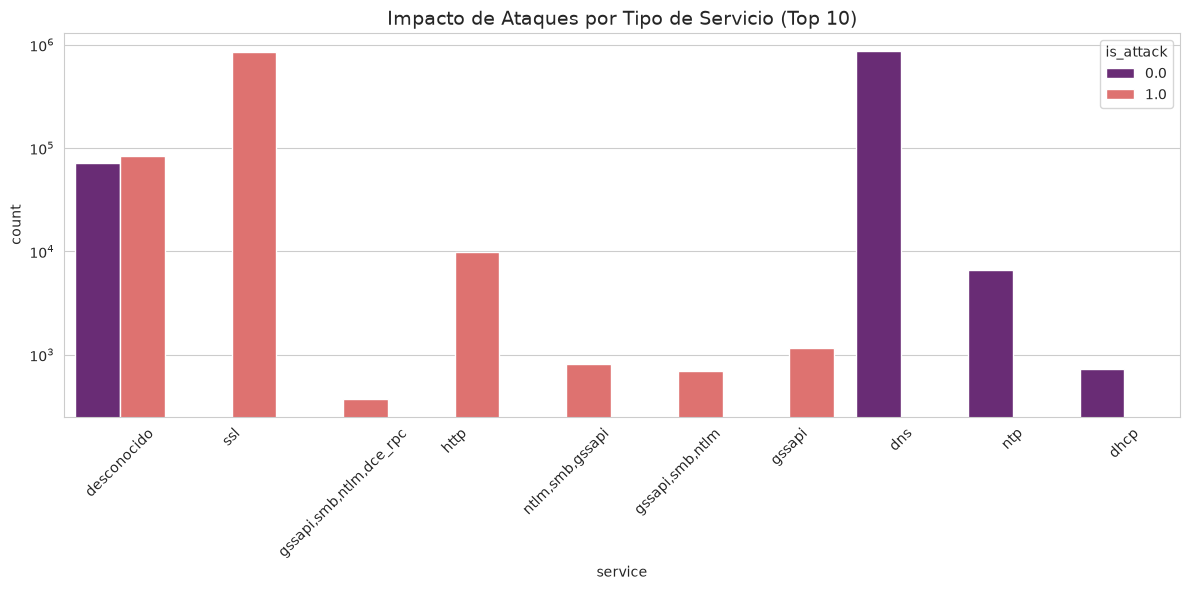

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. LOCALIZACIÓN Y CARGA
archivos_parquet = glob.glob("../data/raw/*.parquet")
print(f"Se han encontrado {len(archivos_parquet)} archivos Parquet.")

lista_df = []
for f in archivos_parquet:
    # Añadir las columnas numéricas que Zeek da para las Edge Features
    columnas_interes = ['service', 'label_tactic', 'src_ip_zeek', 'dest_ip_zeek', 
                        'duration', 'orig_bytes', 'resp_bytes', 'orig_pkts', 'resp_pkts', 'conn_state', 'missed_bytes', 'ts']
    temp_df = pd.read_parquet(f, columns=columnas_interes)
    lista_df.append(temp_df)

df = pd.concat(lista_df, ignore_index=True)
print(f"¡Hecho! Dataset total con {len(df):,} registros cargados.")

# 2. LIMPIEZA Y CODIFICACIÓN DE ETIQUETAS MULTICLASE
df['service'] = df['service'].replace(['-', ''], 'desconocido').fillna('desconocido')

# Limpiar los nulos y símbolos raros de Zeek
df['label_tactic'] = df['label_tactic'].fillna('Benigno').replace(['none', '-', ''], 'Benigno')

# Definir is_attack basándonos en la limpieza correcta
df['is_attack'] = (df['label_tactic'] != 'Benigno').astype(float)

# Codificar las tácticas a números (0, 1, 2...)
encoder_tactics = LabelEncoder()
df['target_class'] = encoder_tactics.fit_transform(df['label_tactic'])

num_clases = len(encoder_tactics.classes_)
print(f"\n--- CLASES DETECTADAS ({num_clases}) ---")
for i, clase in enumerate(encoder_tactics.classes_):
    print(f"Clase {i}: {clase} -> {len(df[df['target_class'] == i]):,} registros")

# 3. DIAGNÓSTICO
resumen = pd.DataFrame({
    'Cantidad': df['service'].value_counts(),
    'Porcentaje (%)': (df['service'].value_counts(normalize=True) * 100).round(2)
})
print("\n--- DISTRIBUCIÓN GLOBAL ---")
print(resumen.head())

# 4. VISUALIZACIÓN
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
top_10 = df['service'].value_counts().head(10).index
df_plot = df[df['service'].isin(top_10)]

sns.countplot(data=df_plot, x='service', hue='is_attack', palette='magma')
plt.title('Impacto de Ataques por Tipo de Servicio (Top 10)', fontsize=14)
plt.yscale('log')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Enrutador y Partición Temporal Estratificada por Clase Train/Val/Test


In [3]:
import numpy as np
import pandas as pd
import torch


# 1. ORDEN CRONOLÓGICO GLOBAL
df = df.sort_values(by=['ts']).reset_index(drop=True)

print("Generando divisiones temporales estratificadas por clase...")

# ========================================================
# 2. PARTICIÓN TEMPORAL ESTRATIFICADA POR CLASE
# ========================================================
# NOTA METODOLÓGICA:
# Este split NO es un corte temporal global único. Como los benignos aparecen
# concentrados al final del dataset, se preserva el orden cronológico DENTRO
# de cada clase/táctica para garantizar representación de todas las clases
# en train/val/test sin sintetizar datos.
train_mask_np = np.zeros(len(df), dtype=bool)
val_mask_np = np.zeros(len(df), dtype=bool)
test_mask_np = np.zeros(len(df), dtype=bool)

for clase in df['target_class'].unique():
    # Al estar df ordenado por 'ts', estos índices preservan la historia interna de la clase
    idx_clase = df[df['target_class'] == clase].index.values

    n_total = len(idx_clase)
    n_train = int(n_total * 0.70)
    n_val = int(n_total * 0.85)

    train_mask_np[idx_clase[:n_train]] = True
    val_mask_np[idx_clase[n_train:n_val]] = True
    test_mask_np[idx_clase[n_val:]] = True

# Verificación de partición disjunta
assert not np.any(train_mask_np & val_mask_np), "Solapamiento Train/Val"
assert not np.any(train_mask_np & test_mask_np), "Solapamiento Train/Test"
assert not np.any(val_mask_np & test_mask_np), "Solapamiento Val/Test"
assert (train_mask_np | val_mask_np | test_mask_np).all(), "Hay filas sin partición"

train_mask = torch.tensor(train_mask_np, dtype=torch.bool)
val_mask = torch.tensor(val_mask_np, dtype=torch.bool)
test_mask = torch.tensor(test_mask_np, dtype=torch.bool)

idx_train = np.where(train_mask_np)[0]
idx_val = np.where(val_mask_np)[0]
idx_test = np.where(test_mask_np)[0]

# --- VERIFICACIÓN DE CLASES POR BLOQUE ---
print("\n[!] Distribución en TRAIN (70% inicial de cada clase):")
print(df[train_mask_np]['label_tactic'].value_counts())
print("\n[!] Distribución en VAL (15% intermedio de cada clase):")
print(df[val_mask_np]['label_tactic'].value_counts())
print("\n[!] Distribución en TEST (15% final de cada clase):")
print(df[test_mask_np]['label_tactic'].value_counts())
print("-" * 50)

# Diagnóstico temporal para dejar claro que no es un corte global único
for nombre, mask_np in [('TRAIN', train_mask_np), ('VAL', val_mask_np), ('TEST', test_mask_np)]:
    print(
        f"{nombre}: ts_min={df.loc[mask_np, 'ts'].min()} | "
        f"ts_max={df.loc[mask_np, 'ts'].max()} | n={mask_np.sum():,}"
    )
print("-" * 50)

# ========================================================
# 3. GRUPOS LÓGICOS DE SERVICIOS
# ========================================================
servicios = df['service'].values
is_ataque = df['is_attack'].astype(int).values
is_ataque_tensor = torch.tensor(is_ataque == 1, dtype=torch.bool)

id_benigno = encoder_tactics.transform(['Benigno'])[0]

mask_web = np.isin(servicios, ['ssl', 'http'])
mask_infra = np.isin(servicios, ['dns', 'ntp', 'dhcp'])
mask_auth = np.isin(servicios, [
    'smb', 'gssapi', 'ntlm', 'dce_rpc',
    'gssapi,smb,ntlm',
    'smb,dce_rpc,ntlm,gssapi',
    'ntlm,dce_rpc,smb,gssapi'
])
mask_gen = ~(mask_web | mask_infra | mask_auth)

mask_web_t = torch.tensor(mask_web, dtype=torch.bool)
mask_infra_t = torch.tensor(mask_infra, dtype=torch.bool)
mask_auth_t = torch.tensor(mask_auth, dtype=torch.bool)
mask_gen_t = torch.tensor(mask_gen, dtype=torch.bool)

# ========================================================
# MÁSCARAS FASE 1: BINARIA GLOBAL / POR SERVICIO
# ========================================================
# Para el portero binario NO se filtran ataques: debe ver clase 0 y clase 1.
train_mask_web = mask_web_t & train_mask
train_mask_infra = mask_infra_t & train_mask
train_mask_auth = mask_auth_t & train_mask
train_mask_gen = mask_gen_t & train_mask

val_mask_web = mask_web_t & val_mask
val_mask_infra = mask_infra_t & val_mask
val_mask_auth = mask_auth_t & val_mask
val_mask_gen = mask_gen_t & val_mask

test_mask_web = mask_web_t & test_mask
test_mask_infra = mask_infra_t & test_mask
test_mask_auth = mask_auth_t & test_mask
test_mask_gen = mask_gen_t & test_mask

# ========================================================
# MÁSCARAS FASE 2: MULTICLASE SOLO ATAQUES
# ========================================================
# Corrección: no se inyectan ataques GEN en expertos Web/Infra/Auth.
# Cada experto multiclase ve únicamente ataques de su propio dominio.
train_mask_web_ataques = train_mask_web & is_ataque_tensor
train_mask_infra_ataques = train_mask_infra & is_ataque_tensor
train_mask_auth_ataques = train_mask_auth & is_ataque_tensor
train_mask_gen_ataques = train_mask_gen & is_ataque_tensor

val_mask_web_ataques = val_mask_web & is_ataque_tensor
val_mask_infra_ataques = val_mask_infra & is_ataque_tensor
val_mask_auth_ataques = val_mask_auth & is_ataque_tensor
val_mask_gen_ataques = val_mask_gen & is_ataque_tensor

test_mask_web_ataques = test_mask_web & is_ataque_tensor
test_mask_infra_ataques = test_mask_infra & is_ataque_tensor
test_mask_auth_ataques = test_mask_auth & is_ataque_tensor
test_mask_gen_ataques = test_mask_gen & is_ataque_tensor

# ========================================================
# DIAGNÓSTICO POR EXPERTO
# ========================================================
def resumen_binario(nombre, mask):
    vals = df.loc[mask.numpy(), 'is_attack'].astype(int).value_counts().sort_index()
    benign = int(vals.get(0, 0))
    attack = int(vals.get(1, 0))
    print(f"{nombre:<12} | total={int(mask.sum()):>8,} | benign={benign:>8,} | attack={attack:>8,}")

print("\n[CHECK] Distribución binaria por experto y split:")
for split_name, masks in {
    'TRAIN': [train_mask_web, train_mask_infra, train_mask_auth, train_mask_gen],
    'VAL': [val_mask_web, val_mask_infra, val_mask_auth, val_mask_gen],
    'TEST': [test_mask_web, test_mask_infra, test_mask_auth, test_mask_gen],
}.items():
    print(f"\n{split_name}")
    for name, m in zip(['WEB', 'INFRA', 'AUTH', 'GEN'], masks):
        resumen_binario(name, m)

print("\n[CHECK] Ataques multiclase por experto:")
for split_name, masks in {
    'TRAIN': [train_mask_web_ataques, train_mask_infra_ataques, train_mask_auth_ataques, train_mask_gen_ataques],
    'VAL': [val_mask_web_ataques, val_mask_infra_ataques, val_mask_auth_ataques, val_mask_gen_ataques],
    'TEST': [test_mask_web_ataques, test_mask_infra_ataques, test_mask_auth_ataques, test_mask_gen_ataques],
}.items():
    print(f"\n{split_name}")
    for name, m in zip(['WEB', 'INFRA', 'AUTH', 'GEN'], masks):
        print(f"{name:<12} | ataques={int(m.sum()):>8,}")

# Inyectamos las máscaras al DataFrame para celdas posteriores
df['train_mask'] = train_mask_np
df['val_mask'] = val_mask_np
df['test_mask'] = test_mask_np


Generando divisiones temporales estratificadas por clase...

[!] Distribución en TRAIN (70% inicial de cada clase):
label_tactic
Benigno                 670676
Credential Access       609831
Reconnaissance           40666
Initial Access            7463
Persistence               4233
Privilege Escalation      4233
Defense Evasion           4233
Exfiltration               391
Name: count, dtype: int64

[!] Distribución en VAL (15% intermedio de cada clase):
label_tactic
Benigno                 143716
Credential Access       130678
Reconnaissance            8714
Initial Access            1599
Defense Evasion            907
Persistence                907
Privilege Escalation       907
Exfiltration                84
Name: count, dtype: int64

[!] Distribución en TEST (15% final de cada clase):
label_tactic
Benigno                 143717
Credential Access       130679
Reconnaissance            8715
Initial Access            1600
Privilege Escalation       908
Persistence                908
D

### Feature Engineering (Nodos Inductivos y Aristas)

Para que el modelo sea verdaderamente inductivo y agnóstico a la IP, las características iniciales de los nodos (X) deben ser estadísticas de comportamiento.


In [4]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
import pandas as pd

print("1. Procesando Características de las Aristas (Edge Features Avanzadas)...")

# El dataframe ya viene ordenado por 'ts' de la celda anterior.
# Se calcula el delta temporal respetando la flecha del tiempo
print("Calculando delta temporal para detectar Persistencia (Beaconing)...")
df['time_since_last_conn'] = df.groupby(['src_ip_zeek', 'dest_ip_zeek'])['ts'].diff().fillna(0.0)

# 1. Añadir variable temporal y missed_bytes
edge_cols = ['duration', 'orig_bytes', 'resp_bytes', 'orig_pkts', 'resp_pkts', 'missed_bytes', 'time_since_last_conn']
df[edge_cols] = df[edge_cols].fillna(0)

# 2. One-Hot Encoding del estado de la conexión
df['conn_state'] = df['conn_state'].fillna('OTH')
conn_state_dummies = pd.get_dummies(df['conn_state'], prefix='state').astype(float)

# 3. Concatenar numéricas y categóricas para tener la matriz total
edge_features_df = pd.concat([df[edge_cols], conn_state_dummies], axis=1)

# 4. Estandarizar (solo con las aristas de train)
scaler_edges = StandardScaler()
scaler_edges.fit(edge_features_df[df['train_mask']].values)
edge_features_np = scaler_edges.transform(edge_features_df.values)

print(f"-> Aristas procesadas. Nuevas dimensiones de Edge Features: {edge_features_np.shape} (Total de conexiones)")


print("\n2. Procesando Características de los Nodos (Node Features Inductivas)...")

# Aislar el train solo para calcular las estadísticas base (Simula la memoria hasta T_train)
df_train = df[df['train_mask']]

# Calcular estadísticas de ORIGEN (Solo sobre Train)
out_stats = df_train.groupby('src_ip_zeek').agg(
    out_bytes_mean=('orig_bytes', 'mean'),
    out_pkts_mean=('orig_pkts', 'mean'),
    out_degree=('orig_bytes', 'count')
)

# Calcular estadísticas de DESTINO (Solo sobre Train)
in_stats = df_train.groupby('dest_ip_zeek').agg(
    in_bytes_mean=('resp_bytes', 'mean'),
    in_pkts_mean=('resp_pkts', 'mean'),
    in_degree=('resp_bytes', 'count')
)

# Sacamos TODAS las IPs únicas del df completo para no dejar al Test sin nodos
# Las IPs nuevas (Out Of Vocabulary) quedarán con estadísticas en 0.0 (Cold Start real)
ips_unicas = pd.unique(df[['src_ip_zeek', 'dest_ip_zeek']].values.ravel('K'))

node_df = pd.DataFrame(index=ips_unicas)
node_df = node_df.join(out_stats).join(in_stats).fillna(0)

# ESCALADO DE NODOS SIN LEAKAGE
ips_train = pd.unique(df_train[['src_ip_zeek', 'dest_ip_zeek']].values.ravel('K'))

scaler_nodes = StandardScaler()
# FIT: Solo con las IPs del Train
scaler_nodes.fit(node_df.loc[ips_train].values)
# TRANSFORM: A todas las IPs del grafo
node_features_np = scaler_nodes.transform(node_df.values)

print(f"-> Nodos procesados con éxito: {len(ips_unicas):,}")

1. Procesando Características de las Aristas (Edge Features Avanzadas)...
Calculando delta temporal para detectar Persistencia (Beaconing)...
-> Aristas procesadas. Nuevas dimensiones de Edge Features: (1916757, 14) (Total de conexiones)

2. Procesando Características de los Nodos (Node Features Inductivas)...
-> Nodos procesados con éxito: 357


### Construcción del Grafo en PyTorch


In [5]:
import torch

print("Construyendo matriz de adyacencia...")
# Codificamos las IPs a índices numéricos (0 a N)
mapeo_ips = {ip: i for i, ip in enumerate(node_df.index)}
df['src_id'] = df['src_ip_zeek'].map(mapeo_ips)
df['dst_id'] = df['dest_ip_zeek'].map(mapeo_ips)

# 1. Matriz de Adyacencia Global (edge_index) [2, num_aristas]
origen = torch.tensor(df['src_id'].values, dtype=torch.long)
destino = torch.tensor(df['dst_id'].values, dtype=torch.long)
edge_index_total = torch.stack([origen, destino], dim=0)

# 2. Tensores de Características (X) y Aristas (Edge_Attr)
x_nodos = torch.tensor(node_features_np, dtype=torch.float)
edge_attr_total = torch.tensor(edge_features_np, dtype=torch.float)

# 3. Etiquetas (Target multiclase)
# IMPORTANTE: CrossEntropyLoss requiere que las etiquetas sean 'long' (enteros)
y_total = torch.tensor(df['target_class'].values, dtype=torch.long)
edge_services = df['service'].values

print(f"Tensor X (Nodos): {x_nodos.shape}")
print(f"Tensor edge_index (Topología): {edge_index_total.shape}")

Construyendo matriz de adyacencia...
Tensor X (Nodos): torch.Size([357, 6])
Tensor edge_index (Topología): torch.Size([2, 1916757])


### Exportación de datos


In [6]:
import os
import json

print("\n--- Exportando datasets estratificados para simulación e histórico ---")
os.makedirs("../data/processed", exist_ok=True)

# 1. Dataset de evaluación/simulación Kafka (TEST estratificado)
df_test_estratificado = df.iloc[idx_test].copy().sort_values(by='ts')
# df_test_estratificado.to_parquet(
#     "../data/processed/dataset_test_estratificado_kafka.parquet",
#     index=False
# )

# 2. Dataset histórico disponible para Neo4j / contexto productivo (TRAIN + VAL estratificado)
df_historico_estratificado = df.loc[train_mask_np | val_mask_np].copy().sort_values(by='ts')
# df_historico_estratificado.to_parquet(
#     "../data/processed/dataset_historico_estratificado_neo4j.parquet",
#     index=False
# )

# Aliases legacy para no romper scripts existentes que esperen estos nombres.
df_test_estratificado.to_parquet(
    "../data/processed/dataset_simulacion_kafka.parquet",
    index=False
)
df_historico_estratificado.to_parquet(
    "../data/processed/dataset_historico_neo4j.parquet",
    index=False
)

# 3. Exportar el orden de columnas de las edge features
columnas_modelo = list(edge_features_df.columns)
with open("../data/processed/columnas_modelo.json", "w") as f:
    json.dump(columnas_modelo, f)

print(f"✅ Test estratificado para Kafka exportado: {len(df_test_estratificado):,} registros.")
print(f"✅ Histórico estratificado Train+Val exportado: {len(df_historico_estratificado):,} registros.")
print("ℹ️ También se han escrito los nombres legacy dataset_simulacion_kafka.parquet y dataset_historico_neo4j.parquet.")



--- Exportando datasets estratificados para simulación e histórico ---
✅ Test estratificado para Kafka exportado: 287,519 registros.
✅ Histórico estratificado Train+Val exportado: 1,629,238 registros.
ℹ️ También se han escrito los nombres legacy dataset_simulacion_kafka.parquet y dataset_historico_neo4j.parquet.


### Arquitectura GraphSAGE (El Modelo)


In [7]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, GATConv

class AdvancedEdgeExpert(torch.nn.Module):
    def __init__(self, node_in_channels, edge_in_channels, hidden_channels, out_classes, conv_type='SAGE', dropout_rate=0.3):
        super(AdvancedEdgeExpert, self).__init__()
        self.conv_type = conv_type
        
        # GraphSAGE: Ideal para capturar densidad volumétrica en vecindarios densos:
        if conv_type == 'SAGE':
            self.conv1 = SAGEConv(node_in_channels, hidden_channels)
            self.conv2 = SAGEConv(hidden_channels, hidden_channels)
            self.conv3 = SAGEConv(hidden_channels, hidden_channels)
        # GAT: Con mecanismo de atención que permite ponderar qué conexiones son críticas y cuáles "ruido":
        elif conv_type == 'GAT':
            heads = 4
            assert hidden_channels % heads == 0, (
                f"hidden_channels ({hidden_channels}) "
                f"debe ser divisible por heads ({heads})"
            )
            self.conv1 = GATConv(node_in_channels, hidden_channels // heads, heads=heads)
            self.conv2 = GATConv(hidden_channels, hidden_channels // heads, heads=heads)
            self.conv3 = GATConv(hidden_channels, hidden_channels, heads=1)

        clf_input_dim = (hidden_channels * 2) + edge_in_channels

        # Arquitectura en forma de embudo
        # BatchNorm1d y Dropout para combatir overfitting
        self.edge_classifier = nn.Sequential(
            nn.Linear(clf_input_dim, hidden_channels),
            nn.BatchNorm1d(hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_channels, hidden_channels // 2),
            nn.ReLU(),
            nn.Linear(hidden_channels // 2, out_classes) 
        )

    def forward(self, x, edge_index_msg, edge_index_pred, edge_attr_pred):
        x = F.relu(self.conv1(x, edge_index_msg))
        x = F.relu(self.conv2(x, edge_index_msg))
        x = self.conv3(x, edge_index_msg)
        
        src = edge_index_pred[0]
        dst = edge_index_pred[1]
        
        edge_features = torch.cat([x[src], x[dst], edge_attr_pred], dim=-1)
        return self.edge_classifier(edge_features)

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Mejoras integradas para robustez y generalización

Cambios aplicados directamente al pipeline corregido:

- Split temporal estratificado por clase, documentado sin presentarlo como corte temporal global.
- Portero binario único entrenado con `train_mask` completo y sin augmentación por táctica.
- Expertos multiclase entrenados solo con ataques de su propio dominio de servicio.
- Message Passing de entrenamiento sobre grafo histórico global de TRAIN, con pérdida restringida al experto.
- Validación inductiva: predicción sobre VAL usando contexto de TRAIN.
- Focal Loss con pesos calculados únicamente sobre clases presentes.
- Exportación de artefactos en CPU para despliegue Docker/PyTorch CPU.
- Exportación de topología histórica Train+Val sin aristas ni nodos exclusivos de Test.
- Métricas de recall de ataques calculadas con lista explícita de etiquetas de ataque.

- Experto multiclase global (`MULTI GLOBAL`) como fallback forense cuando un experto específico no puede entrenarse.


### Bucle de Entrenamiento

El entrenamiento usa Message Passing sobre el grafo histórico global de `TRAIN`, mientras que la pérdida se calcula solo sobre las aristas del experto correspondiente.

La validación se mantiene inductiva: se predicen aristas de `VAL`, pero el contexto de Message Passing sigue siendo únicamente el grafo de `TRAIN`. No se añaden aristas de validación al grafo de mensajes.

Para el portero binario no se aplica augmentación: aprende con todos los datos de `train_mask`. La augmentación se reserva para expertos multiclase y solo duplica aristas ya pertenecientes al propio dominio del experto, sin mezclar servicios.


Además, se entrena un experto multiclase global con todos los ataques de entrenamiento para usarlo como fallback cuando un dominio no disponga de experto multiclase válido.


In [3]:
import numpy as np
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import f1_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Entrenando en: {device}\n")

# --- 1. ETIQUETAS ---
y_binario = torch.tensor(df['is_attack'].astype(int).values, dtype=torch.long).to(device)
is_ataque_tensor = torch.tensor(df['is_attack'].values == 1, dtype=torch.bool)
id_benigno = encoder_tactics.transform(['Benigno'])[0]

# ============================================================
# CONFIGURACIÓN DINÁMICA DE EXPERTOS
# ============================================================

# Si True, omite modelos multiclase que solo vean una táctica en entrenamiento.
# Recomendación inicial: False. WEB puede ser trivial, pero si lo omites
# sin un generalista global entrenado con todas las tácticas, puedes perder
# Credential Access en inferencia.
OMITIR_EXPERTOS_MULTICLASE_TRIVIALES = False

# Dominio de fallback cuando un experto específico no existe o no pudo entrenar.
FALLBACK_MULTICLASE_DOMAIN = "global"

estado_modelos = {}

# --- 2. FASE 1: PORTERO BINARIO ÚNICO ---
model_bin_sage = AdvancedEdgeExpert(
    x_nodos.shape[1],
    edge_attr_total.shape[1],
    256,
    2,
    'SAGE',
    0.3
).to(device)
opt_bin_sage = torch.optim.Adam(model_bin_sage.parameters(), lr=0.001)

# --- 3. FASE 2: COMITÉ MULTICLASE ---
model_multi_web = AdvancedEdgeExpert(x_nodos.shape[1], edge_attr_total.shape[1], 128, num_clases, 'SAGE', 0.3).to(device)
opt_multi_web = torch.optim.Adam(model_multi_web.parameters(), lr=0.005)

model_multi_infra_sage = AdvancedEdgeExpert(x_nodos.shape[1], edge_attr_total.shape[1], 64, num_clases, 'SAGE', 0.2).to(device)
model_multi_infra_gat = AdvancedEdgeExpert(x_nodos.shape[1], edge_attr_total.shape[1], 64, num_clases, 'GAT', 0.2).to(device)
opt_multi_infra_sage = torch.optim.Adam(model_multi_infra_sage.parameters(), lr=0.005)
opt_multi_infra_gat = torch.optim.Adam(model_multi_infra_gat.parameters(), lr=0.001)

model_multi_auth_sage = AdvancedEdgeExpert(x_nodos.shape[1], edge_attr_total.shape[1], 128, num_clases, 'SAGE', 0.4).to(device)
model_multi_auth_gat = AdvancedEdgeExpert(x_nodos.shape[1], edge_attr_total.shape[1], 128, num_clases, 'GAT', 0.4).to(device)
opt_multi_auth_sage = torch.optim.Adam(model_multi_auth_sage.parameters(), lr=0.003)
opt_multi_auth_gat = torch.optim.Adam(model_multi_auth_gat.parameters(), lr=0.001)

model_multi_gen_sage = AdvancedEdgeExpert(x_nodos.shape[1], edge_attr_total.shape[1], 256, num_clases, 'SAGE', 0.5).to(device)
model_multi_gen_gat = AdvancedEdgeExpert(x_nodos.shape[1], edge_attr_total.shape[1], 256, num_clases, 'GAT', 0.5).to(device)
opt_multi_gen_sage = torch.optim.Adam(model_multi_gen_sage.parameters(), lr=0.001)
opt_multi_gen_gat = torch.optim.Adam(model_multi_gen_gat.parameters(), lr=0.001)

# --- 4. EXPERTO MULTICLASE GLOBAL ---
# Fallback forense real: se entrena con todos los ataques de todos los dominios.
# Se usa cuando un experto específico no existe/no pudo entrenar.
model_multi_global_sage = AdvancedEdgeExpert(
    x_nodos.shape[1],
    edge_attr_total.shape[1],
    256,
    num_clases,
    'SAGE',
    0.5
).to(device)
opt_multi_global_sage = torch.optim.Adam(model_multi_global_sage.parameters(), lr=0.001)

# Tensores base en device para entrenamiento
x_nodos = x_nodos.to(device)
edge_index_total = edge_index_total.to(device)
edge_attr_total = edge_attr_total.to(device)
y_total = y_total.to(device)

# Máscaras para el experto multiclase GLOBAL.
# Solo ataques: la fase 2 nunca aprende/produce Benigno.
train_mask_global_ataques = train_mask & is_ataque_tensor
val_mask_global_ataques = val_mask & is_ataque_tensor


def extraer_indices(mascara_train, mascara_val):
    """Extrae índices CPU desde máscaras booleanas. No crea validación sintética."""
    idx_train = torch.where(mascara_train)[0].cpu()
    idx_val = torch.where(mascara_val)[0].cpu()
    return idx_train, idx_val


def aplicar_augmentacion_topologica(
    idx_train_base,
    y_multiclase_global,
    num_clases,
    id_benigno,
    target_muestras=15000
):
    """
    Augmentación solo para Fase 2 multiclase.
    Duplica índices de predicción ya presentes en el experto, sin alterar el grafo
    de Message Passing ni mezclar dominios de servicio.
    """
    y_train_np = y_multiclase_global[idx_train_base.to(y_multiclase_global.device)].detach().cpu().numpy()
    counts = np.bincount(y_train_np, minlength=num_clases)

    indices_extra = []

    for c in np.unique(y_train_np):
        if c == id_benigno:
            continue

        if 0 < counts[c] < target_muestras:
            factor = int(target_muestras / counts[c])
            if factor > 1:
                indices_clase = idx_train_base[y_train_np == c]
                indices_extra.extend(np.tile(indices_clase.numpy(), factor - 1))

    if indices_extra:
        print(f"[*] Augmentación multiclase: +{len(indices_extra):,} aristas duplicadas en loss.")
        return torch.cat([idx_train_base, torch.tensor(indices_extra, dtype=torch.long)])

    return idx_train_base


def calcular_focal_loss_dinamica(
    y_train_base,
    is_multiclass,
    num_clases,
    device,
    smoothing_factor=0.25,
    max_gamma=2.0
):
    """
    Focal Loss con pesos calculados solo sobre clases presentes.
    Evita que clases ausentes contaminen la normalización de pesos.
    """
    n_out = num_clases if is_multiclass else 2
    y_np = y_train_base.detach().cpu().numpy()
    conteo = np.bincount(y_np, minlength=n_out)
    presentes = conteo > 0

    pesos = torch.zeros(n_out, device=device)
    gammas = torch.zeros(n_out, device=device)

    if not np.any(presentes):
        raise ValueError("No hay clases presentes para calcular la loss.")

    max_count = np.max(conteo[presentes])

    for c in np.where(presentes)[0]:
        pesos[c] = 1.0 / (conteo[c] ** smoothing_factor)

        if is_multiclass:
            ratio = max_count / conteo[c]
            gammas[c] = min(max_gamma, 1.0 + np.log10(ratio))
        else:
            gammas[c] = 2.0

    pesos_finales = torch.zeros_like(pesos)
    pesos_finales[presentes] = (pesos[presentes] / pesos[presentes].sum()) * presentes.sum()
    pesos_finales = torch.clamp(pesos_finales, min=0.0)

    gamma_final = gammas[presentes].mean().item()

    return FocalLoss(weight=pesos_finales, gamma=gamma_final)


class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.weight = weight
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.weight is not None:
            focal_loss = focal_loss * self.weight[targets]

        return focal_loss.mean()


def entrenar_experto_gnn(
    nombre,
    modelo,
    optimizador,
    mascara_train,
    mascara_val,
    y_target,
    grafo_global,
    is_multiclass=False,
    epochs=1000,
    paciencia=50
):
    print(f"\n--- Entrenando Experto: {nombre} ---")

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    modelo.to(device)

    x_nodos_local = grafo_global['x_nodos'].to(device)
    edge_index_t = grafo_global['edge_index_total'].to(device)
    edge_attr_t = grafo_global['edge_attr_total'].to(device)
    num_clases = grafo_global['num_clases']
    y_total_global = grafo_global['y_total'].to(device)
    id_benigno_local = grafo_global['id_benigno']

    idx_train_base, idx_val = extraer_indices(mascara_train, mascara_val)

    metadata = {
        "trained": False,
        "name": nombre,
        "is_multiclass": bool(is_multiclass),
        "train_samples": int(len(idx_train_base)),
        "val_samples": int(len(idx_val)),
        "best_f1": None,
        "reason": None,
        "train_classes": []
    }

    if len(idx_train_base) == 0:
        print(f"⚠️ {nombre}: sin muestras de entrenamiento. Se omite.")
        metadata["reason"] = "no_train_samples"
        return metadata

    y_train_base_debug = y_target[idx_train_base.to(y_target.device)].detach().cpu().numpy()
    clases_train = sorted(np.unique(y_train_base_debug).tolist())
    metadata["train_classes"] = [int(c) for c in clases_train]

    if is_multiclass:
        clases_ataque_train = [c for c in clases_train if c != id_benigno_local]

        if len(clases_ataque_train) == 0:
            print(f"⚠️ {nombre}: no hay clases de ataque en entrenamiento. Se omite.")
            metadata["reason"] = "no_attack_classes"
            return metadata

        if OMITIR_EXPERTOS_MULTICLASE_TRIVIALES and len(clases_ataque_train) < 2:
            clase_unica = encoder_tactics.inverse_transform([clases_ataque_train[0]])[0]
            print(
                f"⚠️ {nombre}: solo contiene una táctica ({clase_unica}). "
                f"Se omite por configuración."
            )
            metadata["reason"] = "single_attack_class_omitted"
            return metadata

    else:
        # El binario debería ver clase 0 y clase 1. Si no ocurre, se puede entrenar,
        # pero la métrica será poco informativa. Lo dejamos explícito.
        if len(clases_train) < 2:
            print(
                f"⚠️ {nombre}: el binario solo ve una clase en entrenamiento "
                f"({clases_train}). Se entrenará igualmente, pero revisa el split."
            )

    # ------------------------------------------------------------
    # Augmentación: SOLO multiclase.
    # ------------------------------------------------------------
    if is_multiclass:
        idx_train_pred = aplicar_augmentacion_topologica(
            idx_train_base,
            y_total_global,
            num_clases,
            id_benigno_local
        )
    else:
        idx_train_pred = idx_train_base

    y_train_pred = y_target[idx_train_pred.to(y_target.device)].to(device)

    criterion = calcular_focal_loss_dinamica(
        y_train_pred,
        is_multiclass,
        num_clases,
        device
    )

    # ------------------------------------------------------------
    # Message Passing: grafo histórico global de TRAIN.
    # Loss: solo aristas del experto.
    # ------------------------------------------------------------
    idx_msg_train = torch.where(
        grafo_global['train_mask_global'].to(edge_index_t.device)
    )[0]

    edge_idx_msg_train = edge_index_t[:, idx_msg_train].to(device)

    edge_idx_pred_train = edge_index_t[:, idx_train_pred.to(edge_index_t.device)].to(device)
    edge_attr_pred_train = edge_attr_t[idx_train_pred.to(edge_attr_t.device)].to(device)

    # ------------------------------------------------------------
    # Validación inductiva: se predice VAL, pero el contexto sigue siendo TRAIN.
    # ------------------------------------------------------------
    validacion_disponible = len(idx_val) > 0

    if validacion_disponible:
        idx_val_device = idx_val.to(edge_index_t.device)
        edge_idx_pred_val = edge_index_t[:, idx_val_device].to(device)
        edge_idx_msg_val = edge_idx_msg_train
        edge_attr_pred_val = edge_attr_t[idx_val.to(edge_attr_t.device)].to(device)
        y_val_pred = y_target[idx_val.to(y_target.device)].to(device)
    else:
        print(f"⚠️ {nombre}: sin muestras de validación. Se entrenará sin Early Stopping.")
        edge_idx_pred_val = None
        edge_idx_msg_val = None
        edge_attr_pred_val = None
        y_val_pred = None

    mejor_f1_val = -1.0
    mejor_modelo_pesos = None
    paciencia_cnt = 0

    for epoch in range(epochs):
        modelo.train()
        optimizador.zero_grad()

        out = modelo(
            x_nodos_local,
            edge_idx_msg_train,
            edge_idx_pred_train,
            edge_attr_pred_train
        )

        loss = criterion(out, y_train_pred)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(modelo.parameters(), 1.0)
        optimizador.step()

        if validacion_disponible:
            modelo.eval()
            with torch.no_grad():
                out_v = modelo(
                    x_nodos_local,
                    edge_idx_msg_val,
                    edge_idx_pred_val,
                    edge_attr_pred_val
                )
                preds_v = out_v.argmax(dim=1)
                f1_v = f1_score(
                    y_val_pred.detach().cpu(),
                    preds_v.detach().cpu(),
                    average='macro',
                    zero_division=0
                )

            if f1_v > mejor_f1_val:
                mejor_f1_val = f1_v
                mejor_modelo_pesos = copy.deepcopy(modelo.state_dict())
                paciencia_cnt = 0
            else:
                paciencia_cnt += 1

            if (epoch + 1) % 50 == 0:
                print(
                    f"Ep {epoch+1:03d} | Train Loss: {loss.item():.4f} "
                    f"| Val Macro-F1: {f1_v:.4f}"
                )

            if paciencia_cnt >= paciencia:
                print(
                    f"🛑 Early Stopping en ep {epoch+1}. "
                    f"Mejor Macro-F1: {mejor_f1_val:.4f}"
                )
                break

        else:
            # Sin validación: entrenamiento fijo.
            if (epoch + 1) % 50 == 0:
                print(f"Ep {epoch+1:03d} | Train Loss: {loss.item():.4f}")

    if validacion_disponible and mejor_modelo_pesos is not None:
        modelo.load_state_dict(mejor_modelo_pesos)
        metadata["best_f1"] = float(mejor_f1_val)
    else:
        metadata["best_f1"] = None

    metadata["trained"] = True
    metadata["reason"] = "trained"

    print(f"✅ Experto {nombre} listo.")
    return metadata

# ================= ENTRENAMIENTO EN MASA =================
grafo_global = {
    'x_nodos': x_nodos,
    'edge_index_total': edge_index_total,
    'edge_attr_total': edge_attr_total,
    'num_clases': num_clases,
    'y_total': y_total,
    'train_mask_global': train_mask,
    'val_mask_global': val_mask,
    'id_benigno': id_benigno
}

print(">>> INICIANDO FASE 1 (MODELO BINARIO ÚNICO - FILTRADO)")
estado_modelos["bin_sage"] = entrenar_experto_gnn(
    "BIN. SAGE",
    model_bin_sage,
    opt_bin_sage,
    train_mask,
    val_mask,
    y_binario,
    grafo_global,
    is_multiclass=False,
    epochs=150,
    paciencia=50
)

print("\n>>> INICIANDO FASE 2 (MODELOS MULTICLASE - CLASIFICACIÓN MITRE)")

estado_modelos["multi_web_sage"] = entrenar_experto_gnn(
    "MULTI WEB (SAGE)",
    model_multi_web,
    opt_multi_web,
    train_mask_web_ataques,
    val_mask_web_ataques,
    y_total,
    grafo_global,
    is_multiclass=True,
    epochs=1000
)

estado_modelos["multi_infra_gat"] = entrenar_experto_gnn(
    "MULTI INFRA (GAT)",
    model_multi_infra_gat,
    opt_multi_infra_gat,
    train_mask_infra_ataques,
    val_mask_infra_ataques,
    y_total,
    grafo_global,
    is_multiclass=True,
    epochs=1000
)

estado_modelos["multi_infra_sage"] = entrenar_experto_gnn(
    "MULTI INFRA (SAGE)",
    model_multi_infra_sage,
    opt_multi_infra_sage,
    train_mask_infra_ataques,
    val_mask_infra_ataques,
    y_total,
    grafo_global,
    is_multiclass=True,
    epochs=1000
)

estado_modelos["multi_auth_sage"] = entrenar_experto_gnn(
    "MULTI AUTH (SAGE)",
    model_multi_auth_sage,
    opt_multi_auth_sage,
    train_mask_auth_ataques,
    val_mask_auth_ataques,
    y_total,
    grafo_global,
    is_multiclass=True,
    epochs=1000
)

estado_modelos["multi_auth_gat"] = entrenar_experto_gnn(
    "MULTI AUTH (GAT)",
    model_multi_auth_gat,
    opt_multi_auth_gat,
    train_mask_auth_ataques,
    val_mask_auth_ataques,
    y_total,
    grafo_global,
    is_multiclass=True,
    epochs=1000,
    paciencia=100
)

estado_modelos["multi_gen_sage"] = entrenar_experto_gnn(
    "MULTI GEN (SAGE)",
    model_multi_gen_sage,
    opt_multi_gen_sage,
    train_mask_gen_ataques,
    val_mask_gen_ataques,
    y_total,
    grafo_global,
    is_multiclass=True,
    epochs=1000
)

estado_modelos["multi_gen_gat"] = entrenar_experto_gnn(
    "MULTI GEN (GAT)",
    model_multi_gen_gat,
    opt_multi_gen_gat,
    train_mask_gen_ataques,
    val_mask_gen_ataques,
    y_total,
    grafo_global,
    is_multiclass=True,
    epochs=1000
)

estado_modelos["multi_global_sage"] = entrenar_experto_gnn(
    "MULTI GLOBAL (SAGE)",
    model_multi_global_sage,
    opt_multi_global_sage,
    train_mask_global_ataques,
    val_mask_global_ataques,
    y_total,
    grafo_global,
    is_multiclass=True,
    epochs=1000
)

print("\n[RESUMEN] Estado de entrenamiento de modelos:")
for nombre, estado in estado_modelos.items():
    print(
        f"{nombre:<20} | trained={estado['trained']} "
        f"| reason={estado['reason']} "
        f"| train={estado['train_samples']} "
        f"| val={estado['val_samples']} "
        f"| best_f1={estado['best_f1']}"
    )


Entrenando en: cpu



NameError: name 'df' is not defined

### Evaluación en el Conjunto de Test


In [ ]:
from sklearn.metrics import classification_report, f1_score, recall_score
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Ejecutando inferencia inductiva en cascada con Soft Voting y Threshold Moving...")

todas_las_predicciones = []
todas_las_etiquetas = []
id_benigno = encoder_tactics.transform(['Benigno'])[0]

# --- PREVENCIÓN DE LEAKAGE TOPOLOGICO EN TEST ---
# Contexto disponible durante evaluación: histórico Train+Val. Nunca se incluyen aristas Test.
mascara_historica = (train_mask | val_mask).to(edge_index_total.device)
edge_index_historico = edge_index_total[:, mascara_historica].to(device)

def predecir_cascada_voting(mascara_test, model_bin, lista_modelos_multi, multiplicadores_clases=None):
    if int(mascara_test.sum()) == 0:
        return

    mascara_test_device = mascara_test.to(edge_index_total.device)
    edge_index_test = edge_index_total[:, mascara_test_device].to(device)
    edge_attr_test = edge_attr_total[mascara_test_device].to(device)
    y_test_real = y_total[mascara_test_device].to(device)

    # =================================================================
    # 1. FASE BINARIA
    # =================================================================
    model_bin.eval()
    with torch.no_grad():
        out_bin = model_bin(x_nodos, edge_index_historico, edge_index_test, edge_attr_test)

        probs_bin = F.softmax(out_bin, dim=1)
        umbral_portero = 0.5
        preds_bin = (probs_bin[:, 1] >= umbral_portero).long()

    # =================================================================
    # 2. FASE MULTICLASE
    # =================================================================
    preds_finales = torch.full_like(preds_bin, fill_value=id_benigno)
    idx_ataques = torch.where(preds_bin == 1)[0]

    if len(idx_ataques) > 0 and len(lista_modelos_multi) > 0:
        edge_index_ataques = edge_index_test[:, idx_ataques]
        edge_attr_ataques = edge_attr_test[idx_ataques]

        probabilidades_acumuladas = torch.zeros((len(idx_ataques), num_clases), device=device)

        for mod in lista_modelos_multi:
            mod.eval()
            with torch.no_grad():
                out_multi = mod(x_nodos, edge_index_historico, edge_index_ataques, edge_attr_ataques)
                probs = F.softmax(out_multi, dim=1)
                probabilidades_acumuladas += probs

        scores_finales = probabilidades_acumuladas / len(lista_modelos_multi)
        scores_finales[:, id_benigno] = 0.0

        # Threshold Moving multiclase
        if multiplicadores_clases is not None:
            for clase_idx, factor in multiplicadores_clases.items():
                if clase_idx < scores_finales.shape[1]:
                    scores_finales[:, clase_idx] *= factor

        preds_multi = torch.argmax(scores_finales, dim=1)
        preds_finales[idx_ataques] = preds_multi
    elif len(idx_ataques) > 0 and len(lista_modelos_multi) == 0:
        # No existe experto multiclase para este dominio ni fallback.
        # Para mantener compatibilidad con el encoder, se dejan como Benigno.
        # En producción, detector_mitre.py devolverá Ataque_No_Clasificado.
        print(
            "⚠️ Hay eventos marcados como ataque por el portero, "
            "pero no hay modelo multiclase disponible para clasificarlos."
        )

    todas_las_predicciones.extend(preds_finales.detach().cpu().numpy())
    todas_las_etiquetas.extend(y_test_real.detach().cpu().numpy())


# ==============================================================================
# CONFIGURACIÓN DE MULTIPLICADORES DE INFERENCIA (THRESHOLD MOVING)
# ==============================================================================
multiplicadores_criticos = {}
try:
    id_defense = encoder_tactics.transform(['Defense Evasion'])[0]
    multiplicadores_criticos[id_defense] = 2.0 

    id_privilege = encoder_tactics.transform(['Privilege Escalation'])[0]
    multiplicadores_criticos[id_privilege] = 2.5

    id_persistence = encoder_tactics.transform(['Persistence'])[0]
    multiplicadores_criticos[id_persistence] = 2.5

    id_initial = encoder_tactics.transform(['Initial Access'])[0]
    multiplicadores_criticos[id_initial] = 2.0

    id_exfil = encoder_tactics.transform(['Exfiltration'])[0]
    multiplicadores_criticos[id_exfil] = 2.0

    id_rec = encoder_tactics.transform(['Reconnaissance'])[0]
    multiplicadores_criticos[id_rec] = 2.0

    print("[*] Threshold Moving configurado para capturar clases críticas.")
except Exception as e:
    print(f"⚠️ No se pudieron configurar todos los multiplicadores críticos: {e}")
    multiplicadores_criticos = None

# ==============================================================================
# REGISTRO DINÁMICO DE MODELOS MULTICLASE ENTRENADOS
# ==============================================================================

def modelo_entrenado(nombre):
    return bool(estado_modelos.get(nombre, {}).get("trained", False))

modelos_multi_por_dominio_eval = {
    "web": [],
    "infra": [],
    "auth": [],
    "gen": [],
    "global": []
}

if modelo_entrenado("multi_web_sage"):
    modelos_multi_por_dominio_eval["web"].append(model_multi_web)

if modelo_entrenado("multi_infra_sage"):
    modelos_multi_por_dominio_eval["infra"].append(model_multi_infra_sage)

if modelo_entrenado("multi_infra_gat"):
    modelos_multi_por_dominio_eval["infra"].append(model_multi_infra_gat)

if modelo_entrenado("multi_auth_sage"):
    modelos_multi_por_dominio_eval["auth"].append(model_multi_auth_sage)

if modelo_entrenado("multi_auth_gat"):
    modelos_multi_por_dominio_eval["auth"].append(model_multi_auth_gat)

if modelo_entrenado("multi_gen_sage"):
    modelos_multi_por_dominio_eval["gen"].append(model_multi_gen_sage)

if modelo_entrenado("multi_gen_gat"):
    modelos_multi_por_dominio_eval["gen"].append(model_multi_gen_gat)

if modelo_entrenado("multi_global_sage"):
    modelos_multi_por_dominio_eval["global"].append(model_multi_global_sage)


def obtener_modelos_eval(dominio):
    modelos = modelos_multi_por_dominio_eval.get(dominio, [])

    if len(modelos) > 0:
        return modelos, False

    # Prioridad de fallback:
    # 1) GLOBAL: experto forense entrenado con todos los ataques.
    # 2) GEN: último recurso si GLOBAL no se pudo entrenar/exportar.
    fallback_priority = []
    if FALLBACK_MULTICLASE_DOMAIN:
        fallback_priority.append(FALLBACK_MULTICLASE_DOMAIN)

    for candidato in ["global", "gen"]:
        if candidato not in fallback_priority:
            fallback_priority.append(candidato)

    for fallback_domain in fallback_priority:
        if fallback_domain == dominio:
            continue

        modelos_fallback = modelos_multi_por_dominio_eval.get(fallback_domain, [])

        if len(modelos_fallback) > 0:
            print(
                f"ℹ️ Evaluación: dominio {dominio} sin modelos multiclase entrenados. "
                f"Usando fallback {fallback_domain}."
            )
            return modelos_fallback, True

    print(
        f"⚠️ Evaluación: dominio {dominio} sin modelos multiclase disponibles "
        f"y sin fallback válido."
    )
    return [], False

# ==============================================================================
# EJECUCIÓN DEL COMITÉ EN CASCADA
# ==============================================================================
modelos_web_eval, _ = obtener_modelos_eval("web")
modelos_infra_eval, _ = obtener_modelos_eval("infra")
modelos_auth_eval, _ = obtener_modelos_eval("auth")
modelos_gen_eval, _ = obtener_modelos_eval("gen")

predecir_cascada_voting(
    test_mask_web,
    model_bin_sage,
    modelos_web_eval,
    multiplicadores_clases=multiplicadores_criticos
)

predecir_cascada_voting(
    test_mask_infra,
    model_bin_sage,
    modelos_infra_eval,
    multiplicadores_clases=multiplicadores_criticos
)

predecir_cascada_voting(
    test_mask_auth,
    model_bin_sage,
    modelos_auth_eval,
    multiplicadores_clases=multiplicadores_criticos
)

predecir_cascada_voting(
    test_mask_gen,
    model_bin_sage,
    modelos_gen_eval,
    multiplicadores_clases=multiplicadores_criticos
)

# ==============================================================================
# MÉTRICAS
# ==============================================================================
y_true_global = np.array(todas_las_etiquetas)
preds_global = np.array(todas_las_predicciones)

print("\n--- REPORTE DE EVALUACIÓN (CASCADA + ENSEMBLE + THRESHOLD MOVING) ---")
clases_presentes = np.unique(np.concatenate((y_true_global, preds_global)))
nombres_clases = encoder_tactics.inverse_transform(clases_presentes)
nombres_clases_list = [str(c) for c in nombres_clases]

print(classification_report(
    y_true_global,
    preds_global,
    labels=clases_presentes,
    target_names=nombres_clases_list,
    zero_division=0
))

f1_macro = f1_score(y_true_global, preds_global, average='macro', zero_division=0)
print(f"\n🎯 Macro-F1 Global: {f1_macro:.4f}")

recall_macro = recall_score(y_true_global, preds_global, average='macro', zero_division=0)
print(f"🎯 Macro-Recall Global: {recall_macro:.4f}")

# Recall exclusivamente sobre tácticas de ataque.
mask_ataques = y_true_global != id_benigno
y_true_ataques = y_true_global[mask_ataques]
preds_ataques = preds_global[mask_ataques]

if len(y_true_ataques) > 0:
    attack_labels = [i for i in range(num_clases) if i != id_benigno]
    recall_ataques = recall_score(
        y_true_ataques,
        preds_ataques,
        labels=attack_labels,
        average='macro',
        zero_division=0
    )
    print(f"🎯 Macro-Recall (Solo Ataques): {recall_ataques:.4f}")
else:
    print("⚠️ No se encontraron muestras de ataque en el set de test.")


Ejecutando inferencia inductiva en cascada con Soft Voting y Threshold Moving...
[*] Threshold Moving configurado para capturar clases críticas.
ℹ️ Evaluación: dominio infra sin modelos multiclase entrenados. Usando fallback global.

--- REPORTE DE EVALUACIÓN (CASCADA + ENSEMBLE + THRESHOLD MOVING) ---
                      precision    recall  f1-score   support

             Benigno       1.00      1.00      1.00    143717
   Credential Access       1.00      1.00      1.00    130679
     Defense Evasion       0.00      0.00      0.00       908
        Exfiltration       0.23      0.71      0.35        84
      Initial Access       0.99      0.45      0.62      1600
         Persistence       0.23      0.59      0.34       908
Privilege Escalation       0.25      0.37      0.30       908
      Reconnaissance       0.99      0.98      0.98      8715

            accuracy                           0.99    287519
           macro avg       0.59      0.64      0.57    287519
        weig

In [ ]:
import pandas as pd
import numpy as np

# ==============================================================================
# ANÁLISIS FORENSE DE FALSOS NEGATIVOS (Ataques que evadieron el sistema)
# ==============================================================================
print("\n" + "="*70)
print("🔍 ANÁLISIS DE FALSOS NEGATIVOS (ATAQUES PREDICHOS COMO BENIGNO)")
print("="*70)

# 1. Crear una máscara booleana para cazar los Falsos Negativos
mask_fn = (y_true_global != id_benigno) & (preds_global == id_benigno)

# Extraer las tácticas reales de los ataques que se escaparon
y_true_escapados = y_true_global[mask_fn]

if len(y_true_escapados) == 0:
    print("✅ Ningún ataque logró evadir el sistema haciéndose pasar por tráfico benigno.")
else:
    # 2. Resumen Estadístico (Nivel Táctico)
    tacticas_escapadas = encoder_tactics.inverse_transform(y_true_escapados)
    resumen_fn = pd.Series(tacticas_escapadas).value_counts()
    
    print(f"⚠️ Un total de {len(y_true_escapados):,} paquetes maliciosos evadieron el sistema.")
    print("\nDesglose de tácticas evadidas:")
    for tactica, cantidad in resumen_fn.items():
        print(f"  -> {tactica}: {cantidad:,} paquetes")
    
    # 3. Mapear al DataFrame original
    # Reconstruir el subconjunto de test agrupando los servicios en el
    # mismo orden exacto en el que se llama a 'predecir_cascada_voting'
    df_test_web = df[test_mask_web.cpu().numpy()]
    df_test_infra = df[test_mask_infra.cpu().numpy()]
    df_test_auth = df[test_mask_auth.cpu().numpy()]
    df_test_gen = df[test_mask_gen.cpu().numpy()]
    
    df_test_eval = pd.concat([df_test_web, df_test_infra, df_test_auth, df_test_gen]).copy()
    df_test_eval['prediccion_id'] = preds_global
    
    # Filtrar el DataFrame original para quedarse solo con los fallos reales
    df_fallos_criticos = df_test_eval[(df_test_eval['target_class'] != id_benigno) & (df_test_eval['prediccion_id'] == id_benigno)]
    
    print("\n🔎 Muestra de 5 conexiones críticas que evadieron el modelo:")
    columnas_interes = ['ts', 'src_ip_zeek', 'dest_ip_zeek', 'service', 'label_tactic']
    
    # Mostrar los primeros 5 casos con las variables clave de Zeek
    print(df_fallos_criticos[columnas_interes].head(5).to_string(index=False))


🔍 ANÁLISIS DE FALSOS NEGATIVOS (ATAQUES PREDICHOS COMO BENIGNO)
⚠️ Un total de 11 paquetes maliciosos evadieron el sistema.

Desglose de tácticas evadidas:
  -> Reconnaissance: 11 paquetes

🔎 Muestra de 5 conexiones críticas que evadieron el modelo:
          ts  src_ip_zeek dest_ip_zeek     service   label_tactic
1.711324e+09 143.88.10.12 143.88.11.11 desconocido Reconnaissance
1.711498e+09 143.88.14.11  143.88.15.1 desconocido Reconnaissance
1.711499e+09 143.88.12.12  143.88.13.1 desconocido Reconnaissance
1.711499e+09 143.88.15.10  143.88.1.10 desconocido Reconnaissance
1.711499e+09  143.88.5.14   143.88.6.1 desconocido Reconnaissance


### Exportar umbrales para Threshold Moving


In [ ]:
import json
import os

print("Preparando la exportación de umbrales para producción...")

# 1. Definir el umbral para el Portero Binario
umbral_binario_optimo = 0.50 

# 2. Inicializar la lista de umbrales multiclase (Fase 2)
num_clases_totales = len(encoder_tactics.classes_)
umbrales_multiclase = [1.0] * num_clases_totales

# 3. Aplicar la conversión (Threshold = 1 / Multiplicador)
if multiplicadores_criticos is not None:
    for id_clase, factor in multiplicadores_criticos.items():
        if factor > 0:
            umbral_equivalente = round(1.0 / factor, 4)
            umbrales_multiclase[id_clase] = umbral_equivalente
            
            nombre_tactica = encoder_tactics.inverse_transform([id_clase])[0]
            print(f"  -> Táctica '{nombre_tactica}' | Multiplicador: {factor}x ===> Umbral: {umbral_equivalente}")

# 4. Ensamblar el diccionario final
umbrales_exportar = {
    "binario": umbral_binario_optimo,
    "multiclase": umbrales_multiclase
}

# 5. Exportar a JSON en la carpeta de configuración
ruta_exportacion = "../models/config/umbrales_optimos.json"

os.makedirs(os.path.dirname(ruta_exportacion), exist_ok=True)
with open(ruta_exportacion, "w") as f:
    json.dump(umbrales_exportar, f, indent=4)

print(f"\n✅ ¡Exportación completada con éxito en: {ruta_exportacion}!")
print("Contenido del JSON generado:")
print(json.dumps(umbrales_exportar, indent=4))

Preparando la exportación de umbrales para producción...
  -> Táctica 'Defense Evasion' | Multiplicador: 2.0x ===> Umbral: 0.5
  -> Táctica 'Privilege Escalation' | Multiplicador: 2.5x ===> Umbral: 0.4
  -> Táctica 'Persistence' | Multiplicador: 2.5x ===> Umbral: 0.4
  -> Táctica 'Initial Access' | Multiplicador: 2.0x ===> Umbral: 0.5
  -> Táctica 'Exfiltration' | Multiplicador: 2.0x ===> Umbral: 0.5
  -> Táctica 'Reconnaissance' | Multiplicador: 2.0x ===> Umbral: 0.5

✅ ¡Exportación completada con éxito en: ../models/config/umbrales_optimos.json!
Contenido del JSON generado:
{
    "binario": 0.5,
    "multiclase": [
        1.0,
        1.0,
        0.5,
        0.5,
        0.5,
        0.4,
        0.4,
        0.5
    ]
}


### Exportar modelos (con pesos y codificadores)


In [ ]:
import joblib
import os
import json
import torch
import numpy as np
import pandas as pd

print("Guardando el Clasificador Jerárquico Híbrido para Producción...")
os.makedirs("../models", exist_ok=True)
os.makedirs("../models/encoders", exist_ok=True)


def state_dict_cpu(model):
    """Exporta pesos en CPU para despliegue portable en Docker CPU/GPU."""
    return {k: v.detach().cpu() for k, v in model.state_dict().items()}


# ============================================================
# EXPORTACIÓN DINÁMICA DE MODELOS ENTRENADOS
# ============================================================

os.makedirs("../models/config", exist_ok=True)

model_specs = {
    "bin_sage": {
        "role": "binary",
        "domain": "global",
        "filename": "bin_sage.pth",
        "hidden_channels": 256,
        "out_classes": 2,
        "conv_type": "SAGE",
        "dropout_rate": 0.3,
        "model": model_bin_sage
    },
    "multi_web_sage": {
        "role": "multiclass",
        "domain": "web",
        "filename": "multi_web_sage.pth",
        "hidden_channels": 128,
        "out_classes": "num_clases",
        "conv_type": "SAGE",
        "dropout_rate": 0.3,
        "model": model_multi_web
    },
    "multi_infra_sage": {
        "role": "multiclass",
        "domain": "infra",
        "filename": "multi_infra_sage.pth",
        "hidden_channels": 64,
        "out_classes": "num_clases",
        "conv_type": "SAGE",
        "dropout_rate": 0.2,
        "model": model_multi_infra_sage
    },
    "multi_infra_gat": {
        "role": "multiclass",
        "domain": "infra",
        "filename": "multi_infra_gat.pth",
        "hidden_channels": 64,
        "out_classes": "num_clases",
        "conv_type": "GAT",
        "dropout_rate": 0.2,
        "model": model_multi_infra_gat
    },
    "multi_auth_sage": {
        "role": "multiclass",
        "domain": "auth",
        "filename": "multi_auth_sage.pth",
        "hidden_channels": 128,
        "out_classes": "num_clases",
        "conv_type": "SAGE",
        "dropout_rate": 0.4,
        "model": model_multi_auth_sage
    },
    "multi_auth_gat": {
        "role": "multiclass",
        "domain": "auth",
        "filename": "multi_auth_gat.pth",
        "hidden_channels": 128,
        "out_classes": "num_clases",
        "conv_type": "GAT",
        "dropout_rate": 0.4,
        "model": model_multi_auth_gat
    },
    "multi_gen_sage": {
        "role": "multiclass",
        "domain": "gen",
        "filename": "multi_gen_sage.pth",
        "hidden_channels": 256,
        "out_classes": "num_clases",
        "conv_type": "SAGE",
        "dropout_rate": 0.5,
        "model": model_multi_gen_sage
    },
    "multi_gen_gat": {
        "role": "multiclass",
        "domain": "gen",
        "filename": "multi_gen_gat.pth",
        "hidden_channels": 256,
        "out_classes": "num_clases",
        "conv_type": "GAT",
        "dropout_rate": 0.5,
        "model": model_multi_gen_gat
    },
    "multi_global_sage": {
        "role": "multiclass",
        "domain": "global",
        "filename": "multi_global_sage.pth",
        "hidden_channels": 256,
        "out_classes": "num_clases",
        "conv_type": "SAGE",
        "dropout_rate": 0.5,
        "model": model_multi_global_sage
    },
}

manifest = {
    "version": 1,
    "fallback_multiclass_domain": FALLBACK_MULTICLASE_DOMAIN,
    "fallback_priority": [FALLBACK_MULTICLASE_DOMAIN, "global", "gen"],
    "allow_multiclass_fallback": True,
    "models": {},
    "skipped_models": {},
}

for nombre, spec in model_specs.items():
    estado = estado_modelos.get(nombre, {"trained": False, "reason": "not_registered"})

    if estado.get("trained", False):
        torch.save(
            state_dict_cpu(spec["model"]),
            os.path.join("../models", spec["filename"])
        )

        manifest["models"][nombre] = {
            "role": spec["role"],
            "domain": spec["domain"],
            "filename": spec["filename"],
            "hidden_channels": spec["hidden_channels"],
            "out_classes": spec["out_classes"],
            "conv_type": spec["conv_type"],
            "dropout_rate": spec["dropout_rate"],
            "trained": True,
            "exported": True,
            "train_samples": estado.get("train_samples"),
            "val_samples": estado.get("val_samples"),
            "best_f1": estado.get("best_f1"),
            "train_classes": estado.get("train_classes", []),
        }

        print(f"✅ Exportado {nombre} -> {spec['filename']}")

    else:
        manifest["skipped_models"][nombre] = {
            "role": spec["role"],
            "domain": spec["domain"],
            "filename": spec["filename"],
            "trained": False,
            "exported": False,
            "reason": estado.get("reason", "unknown"),
            "train_samples": estado.get("train_samples"),
            "val_samples": estado.get("val_samples"),
            "train_classes": estado.get("train_classes", []),
        }

        stale_path = os.path.join("../models", spec["filename"])
        if os.path.exists(stale_path):
            os.remove(stale_path)
            print(f"🧹 Eliminado modelo obsoleto: {spec['filename']}")

        print(f"⏭️ No exportado {nombre}: {estado.get('reason', 'unknown')}")

with open("../models/config/model_manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2, ensure_ascii=False)

print("✅ Manifiesto exportado en ../models/config/model_manifest.json")

# Guardamos Scalers y Encoders
joblib.dump(scaler_edges, "../models/encoders/scaler_edges.pkl")
joblib.dump(scaler_nodes, "../models/encoders/scaler_nodes.pkl")
joblib.dump(encoder_tactics, "../models/encoders/encoder_tactics.pkl")

# Exportación histórica SIN leakage del conjunto de evaluación.
# El detector arrancará con Train+Val, nunca con aristas ni nodos exclusivos de Test.
mascara_historica_export_np = train_mask_np | val_mask_np
df_historico_export = df.loc[mascara_historica_export_np].copy().sort_values(by='ts')

ips_historicas = pd.unique(
    df_historico_export[['src_ip_zeek', 'dest_ip_zeek']].values.ravel('K')
)

mapeo_ips_historico = {ip: i for i, ip in enumerate(ips_historicas)}

# Remapeo de edge_index histórico para que sea autocontenido y no exponga IDs de test.
src_hist = df_historico_export['src_ip_zeek'].map(mapeo_ips_historico).values
dst_hist = df_historico_export['dest_ip_zeek'].map(mapeo_ips_historico).values
edge_index_historico_export = torch.tensor(
    np.vstack([src_hist, dst_hist]),
    dtype=torch.long
)

# Reordenamos x_nodos al mismo orden del mapeo histórico exportado.
old_ids = torch.tensor([mapeo_ips[ip] for ip in ips_historicas], dtype=torch.long)
x_nodos_historico_export = x_nodos.detach().cpu()[old_ids]

# Node features históricas alineadas al mapeo exportado.
node_df_historico_export = node_df.loc[ips_historicas].copy()

joblib.dump(mapeo_ips_historico, "../models/encoders/mapeo_ips.pkl")
torch.save(x_nodos_historico_export, "../models/encoders/x_nodos_entrenamiento.pt")
torch.save(edge_index_historico_export, "../models/encoders/edge_index_entrenamiento.pt")
node_df_historico_export.to_pickle("../models/encoders/node_features_historicas.pkl")

joblib.dump(
    list(node_df_historico_export.columns),
    "../models/encoders/node_columns.pkl"
)

print("¡Modelos exportados con éxito!")
print(f"IPs históricas exportadas: {len(mapeo_ips_historico):,}")
print(f"x_nodos exportado: {tuple(x_nodos_historico_export.shape)}")
print(f"edge_index histórico exportado: {tuple(edge_index_historico_export.shape)}")


Guardando el Clasificador Jerárquico Híbrido para Producción...
✅ Exportado bin_sage -> bin_sage.pth
✅ Exportado multi_web_sage -> multi_web_sage.pth
🧹 Eliminado modelo obsoleto: multi_infra_sage.pth
⏭️ No exportado multi_infra_sage: no_train_samples
🧹 Eliminado modelo obsoleto: multi_infra_gat.pth
⏭️ No exportado multi_infra_gat: no_train_samples
✅ Exportado multi_auth_sage -> multi_auth_sage.pth
✅ Exportado multi_auth_gat -> multi_auth_gat.pth
✅ Exportado multi_gen_sage -> multi_gen_sage.pth
✅ Exportado multi_gen_gat -> multi_gen_gat.pth
✅ Exportado multi_global_sage -> multi_global_sage.pth
✅ Manifiesto exportado en ../models/config/model_manifest.json
¡Modelos exportados con éxito!
IPs históricas exportadas: 357
x_nodos exportado: (357, 6)
edge_index histórico exportado: (2, 1629238)


### Comparativa experimental con modelos baseline tabulares

RandomForest/XGBoost tabular:
    edge_attr + x_src + x_dst
    sin Message Passing

GNN:
    edge_attr + x_src + x_dst
    con Message Passing sobre edge_index

In [ ]:
# ==============================================================================
# BASELINES TABULARES: RANDOM FOREST / XGBOOST
# ==============================================================================

import time
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    matthews_corrcoef
)

SEED = 42

def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)

train_mask_np = to_numpy(train_mask).astype(bool)
val_mask_np = to_numpy(val_mask).astype(bool)
test_mask_np = to_numpy(test_mask).astype(bool)

y_bin_np = df["is_attack"].astype(int).values
y_multi_np = to_numpy(y_total).astype(int)

edge_attr_np = to_numpy(edge_attr_total).astype(np.float32)
edge_index_np = to_numpy(edge_index_total).astype(np.int64)
x_nodos_np = to_numpy(x_nodos).astype(np.float32)

src_ids = edge_index_np[0]
dst_ids = edge_index_np[1]

# Baseline tabular fuerte: atributos de arista + estadísticas de nodo origen/destino.
X_tabular = np.concatenate(
    [
        edge_attr_np,
        x_nodos_np[src_ids],
        x_nodos_np[dst_ids],
    ],
    axis=1
).astype(np.float32)

print("X_tabular:", X_tabular.shape)
print("Train:", train_mask_np.sum(), "Val:", val_mask_np.sum(), "Test:", test_mask_np.sum())

In [ ]:
# ==============================================================================
# FUNCIONES DE EVALUACIÓN PARA BASELINE TABULAR EN CASCADA
# ==============================================================================

attack_labels = [i for i in range(num_clases) if i != id_benigno]
target_names = list(encoder_tactics.classes_)

def buscar_umbral_binario(probs_ataque_val, y_val_bin):
    """
    Selecciona el umbral binario que maximiza Macro-F1 en validación.
    """
    mejor_umbral = 0.5
    mejor_f1 = -1.0

    for thr in np.linspace(0.05, 0.95, 91):
        pred = (probs_ataque_val >= thr).astype(int)
        f1 = f1_score(y_val_bin, pred, average="macro", zero_division=0)

        if f1 > mejor_f1:
            mejor_f1 = f1
            mejor_umbral = float(thr)

    return mejor_umbral, mejor_f1


def predecir_cascada_tabular(modelo_bin, modelo_multi, X, umbral, label_encoder_multi=None):
    """
    Cascada tabular:
    1. Modelo binario decide Benigno/Ataque.
    2. Si Ataque, modelo multiclase predice táctica MITRE.
    """
    probs_bin = modelo_bin.predict_proba(X)
    probs_ataque = probs_bin[:, 1]

    pred_bin = (probs_ataque >= umbral).astype(int)

    pred_final = np.full(X.shape[0], id_benigno, dtype=int)
    idx_ataque = np.where(pred_bin == 1)[0]

    if len(idx_ataque) > 0:
        pred_multi = modelo_multi.predict(X[idx_ataque])

        if label_encoder_multi is not None:
            pred_multi = label_encoder_multi.inverse_transform(pred_multi)

        pred_final[idx_ataque] = pred_multi.astype(int)

    return probs_ataque, pred_bin, pred_final


def evaluar_cascada_tabular(nombre, modelo_bin, modelo_multi, X_val, X_test, label_encoder_multi=None):
    """
    Ajusta umbral binario en validación y evalúa cascada completa en test.
    """
    y_val_bin = y_bin_np[val_mask_np]
    y_test_bin = y_bin_np[test_mask_np]
    y_test_multi = y_multi_np[test_mask_np]

    probs_val = modelo_bin.predict_proba(X_val)[:, 1]
    umbral, f1_val = buscar_umbral_binario(probs_val, y_val_bin)

    t0 = time.perf_counter()
    probs_test, pred_bin_test, pred_final_test = predecir_cascada_tabular(
        modelo_bin,
        modelo_multi,
        X_test,
        umbral,
        label_encoder_multi=label_encoder_multi
    )
    t1 = time.perf_counter()

    total_s = t1 - t0
    ms_evento = (total_s / len(X_test)) * 1000
    throughput = len(X_test) / total_s if total_s > 0 else np.inf

    print(f"\n================ {nombre} ================")
    print(f"Umbral binario óptimo en VAL: {umbral:.3f} | Macro-F1 VAL binario: {f1_val:.4f}")
    print(f"Latencia media TEST: {ms_evento:.6f} ms/evento")
    print(f"Throughput TEST: {throughput:,.2f} eventos/s")

    print("\n--- Reporte binario TEST ---")
    print(classification_report(
        y_test_bin,
        pred_bin_test,
        target_names=["Benigno", "Ataque"],
        zero_division=0
    ))

    print("\n--- Reporte MITRE final TEST ---")
    print(classification_report(
        y_test_multi,
        pred_final_test,
        labels=list(range(num_clases)),
        target_names=target_names,
        zero_division=0
    ))

    acc = accuracy_score(y_test_multi, pred_final_test)
    macro_f1 = f1_score(
        y_test_multi,
        pred_final_test,
        labels=list(range(num_clases)),
        average="macro",
        zero_division=0
    )
    macro_recall = recall_score(
        y_test_multi,
        pred_final_test,
        labels=list(range(num_clases)),
        average="macro",
        zero_division=0
    )
    macro_recall_attacks = recall_score(
        y_test_multi,
        pred_final_test,
        labels=attack_labels,
        average="macro",
        zero_division=0
    )
    mcc = matthews_corrcoef(y_test_multi, pred_final_test)

    try:
        roc_auc_bin = roc_auc_score(y_test_bin, probs_test)
    except Exception:
        roc_auc_bin = np.nan

    resumen = {
        "modelo": nombre,
        "umbral_binario": umbral,
        "accuracy_global": acc,
        "macro_f1_global": macro_f1,
        "macro_recall_global": macro_recall,
        "macro_recall_ataques": macro_recall_attacks,
        "mcc_global": mcc,
        "roc_auc_binario": roc_auc_bin,
        "latencia_ms_evento": ms_evento,
        "throughput_eventos_s": throughput,
    }

    return resumen, pred_final_test

In [ ]:
# ==============================================================================
# BASELINE 1: RANDOM FOREST TABULAR
# ==============================================================================

X_train = X_tabular[train_mask_np]
X_val = X_tabular[val_mask_np]
X_test = X_tabular[test_mask_np]

y_train_bin = y_bin_np[train_mask_np]
y_train_multi = y_multi_np[train_mask_np]

mask_train_ataques = train_mask_np & (y_bin_np == 1)

X_train_ataques = X_tabular[mask_train_ataques]
y_train_ataques = y_multi_np[mask_train_ataques]

print("Entrenando Random Forest binario...")
t0 = time.perf_counter()

rf_bin = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=SEED
)
rf_bin.fit(X_train, y_train_bin)

t1 = time.perf_counter()
print(f"RF binario entrenado en {(t1 - t0):.2f} s")

print("Entrenando Random Forest multiclase MITRE...")
t0 = time.perf_counter()

rf_multi = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=SEED
)
rf_multi.fit(X_train_ataques, y_train_ataques)

t1 = time.perf_counter()
print(f"RF multiclase entrenado en {(t1 - t0):.2f} s")

res_rf, preds_rf = evaluar_cascada_tabular(
    "RandomForest Tabular Cascade",
    rf_bin,
    rf_multi,
    X_val,
    X_test
)

res_rf

In [4]:
# ==============================================================================
# BASELINE 2: XGBOOST TABULAR
# ==============================================================================

try:
    from xgboost import XGBClassifier
    from sklearn.preprocessing import LabelEncoder

    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False
    print("xgboost no está instalado. Instala con: pip install xgboost")


if HAS_XGBOOST:
    n_pos = max(1, int((y_train_bin == 1).sum()))
    n_neg = max(1, int((y_train_bin == 0).sum()))
    scale_pos_weight = n_neg / n_pos

    print("Entrenando XGBoost binario...")
    t0 = time.perf_counter()

    xgb_bin = XGBClassifier(
        n_estimators=400,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        scale_pos_weight=scale_pos_weight,
        random_state=SEED,
        n_jobs=-1
    )
    xgb_bin.fit(X_train, y_train_bin)

    t1 = time.perf_counter()
    print(f"XGB binario entrenado en {(t1 - t0):.2f} s")

    # XGBoost multiclase necesita etiquetas 0..K-1 para las clases presentes.
    le_attack = LabelEncoder()
    y_train_ataques_xgb = le_attack.fit_transform(y_train_ataques)

    print("Entrenando XGBoost multiclase MITRE...")
    t0 = time.perf_counter()

    xgb_multi = XGBClassifier(
        n_estimators=400,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        num_class=len(le_attack.classes_),
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=SEED,
        n_jobs=-1
    )
    xgb_multi.fit(X_train_ataques, y_train_ataques_xgb)

    t1 = time.perf_counter()
    print(f"XGB multiclase entrenado en {(t1 - t0):.2f} s")

    res_xgb, preds_xgb = evaluar_cascada_tabular(
        "XGBoost Tabular Cascade",
        xgb_bin,
        xgb_multi,
        X_val,
        X_test,
        label_encoder_multi=le_attack
    )

    res_xgb

xgboost no está instalado. Instala con: pip install xgboost


In [5]:
# ==============================================================================
# COMPARATIVA FINAL: BASELINES TABULARES VS GNN
# ==============================================================================

resultados_baseline = [res_rf]

if "res_xgb" in globals():
    resultados_baseline.append(res_xgb)

df_baselines = pd.DataFrame(resultados_baseline)
display(df_baselines)

os.makedirs("../models/evaluation", exist_ok=True)
df_baselines.to_csv("../models/evaluation/resultados_baselines_tabulares.csv", index=False)

print("Resultados guardados en ../models/evaluation/resultados_baselines_tabulares.csv")

NameError: name 'res_rf' is not defined

### Limpiar caché


In [ ]:
import gc
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
